# Análisis de Datos Tecator: Regresión Lineal vs PLS

Este notebook compara el rendimiento de la Regresión Lineal multivariable frente a la Regresión de Mínimos Cuadrados Parciales (PLS) utilizando el dataset Tecator.

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error

## 1. Carga del Dataset

El dataset **Tecator** es un estándar en quimiometría. Contiene datos de muestras de carne analizadas mediante un espectrómetro infrarrojo cercano (NIR).

### Contenido:
* **X (Predictoras):** 100 canales de absorbancia (longitudes de onda entre 850 y 1050 nm).
* **y (Objetivo):** Porcentaje de grasa determinado analíticamente.

El objetivo es predecir el contenido de grasa a partir de la firma espectral, lo cual es ideal para modelos como **PLS** debido a la alta correlación entre las longitudes de onda continuas.

In [97]:
print("Cargando datos de Tecator...")
tecator = fetch_openml(data_id=505, as_frame=True, parser='auto')
X = tecator.data.iloc[:, :100]  # Tomamos estrictamente los 100 canales de luz
y = np.array(tecator.target).astype(float) # Porcentaje de grasa

Cargando datos de Tecator...


## 2. Preprocesamiento
Dividimos los datos en conjuntos de entrenamiento y prueba, y aplicamos estandarización.

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Entrenamiento de Modelos
Entrenamos una Regresión Lineal clásica y un modelo PLS con 6 componentes.

In [99]:
# Modelo 1: Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Modelo 2: PLS
n_comp = 6 
pls = PLSRegression(n_components=n_comp)
pls.fit(X_train_scaled, y_train)
y_pred_pls = pls.predict(X_test_scaled)

## 4. Evaluación de Métricas
Calculamos R2 y RMSE para ambos modelos.

In [100]:
def calcular_metricas(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return r2, rmse

r2_lr, rmse_lr = calcular_metricas(y_test, y_pred_lr)
r2_pls, rmse_pls = calcular_metricas(y_test, y_pred_pls)

print("\n" + "="*40)
print(f"PRECISIONES EN EL SET DE PRUEBA")
print("="*40)
print(f"Regresión Lineal (100 variables):")
print(f"  - R2:   {r2_lr:.4f}")
print(f"  - RMSE: {rmse_lr:.2f}% de grasa")
print("-" * 40)
print(f"PLS ({n_comp} componentes):")
print(f"  - R2:   {r2_pls:.4f}")
print(f"  - RMSE: {rmse_pls:.2f}% de grasa")
print("="*40)


PRECISIONES EN EL SET DE PRUEBA
Regresión Lineal (100 variables):
  - R2:   0.9267
  - RMSE: 3.86% de grasa
----------------------------------------
PLS (6 componentes):
  - R2:   0.9398
  - RMSE: 3.50% de grasa


## 5. Visualización de Coeficientes
Comparamos la estabilidad de los coeficientes entre ambos modelos.

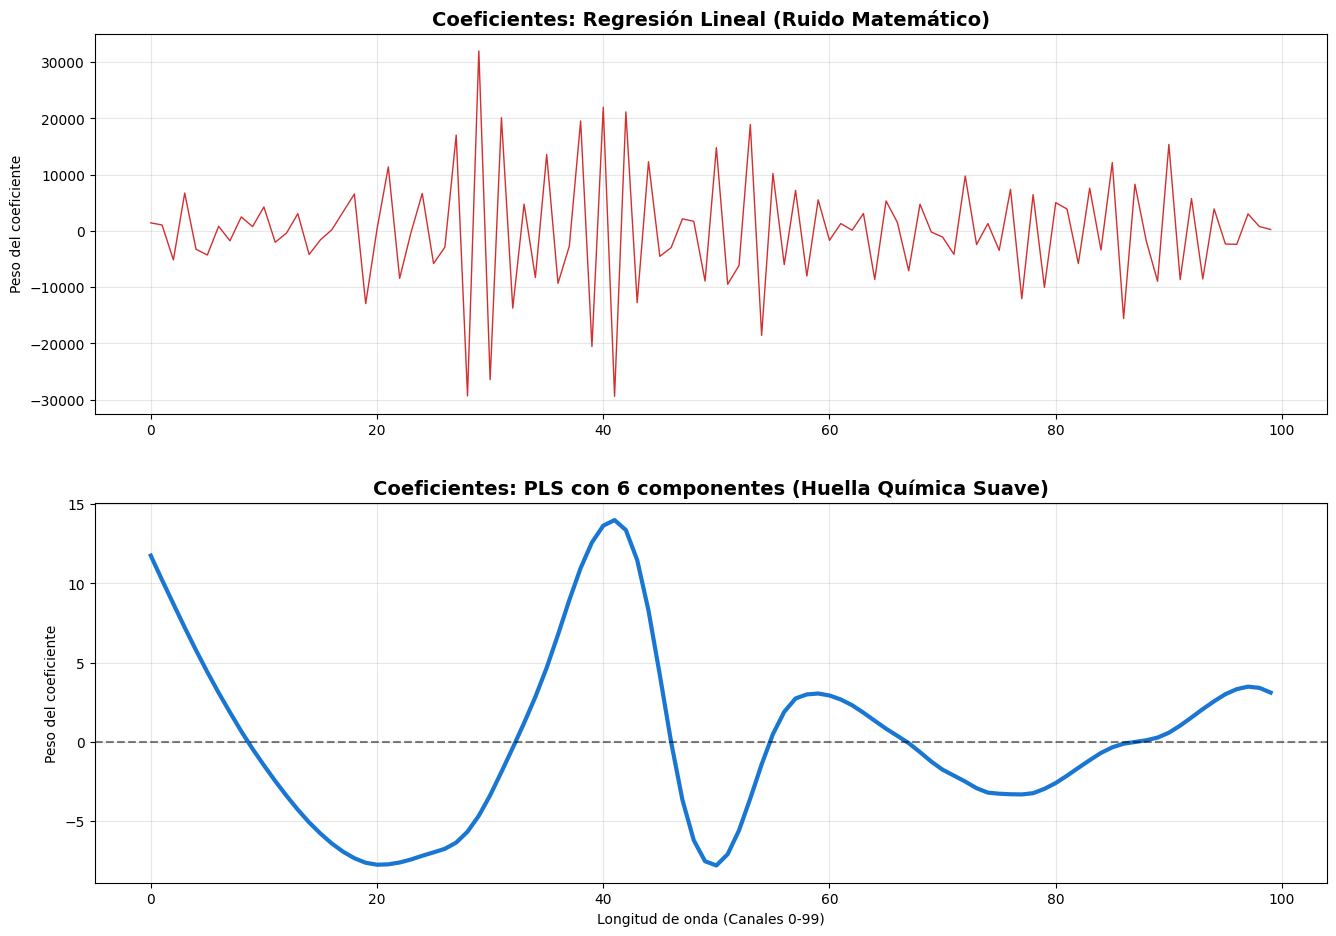

In [101]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico Regresión Lineal
ax1.plot(lr.coef_, color='#d32f2f', linewidth=1)
ax1.set_title('Coeficientes: Regresión Lineal (Ruido Matemático)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Peso del coeficiente')
ax1.grid(alpha=0.3)

# Gráfico PLS
ax2.plot(pls.coef_.ravel(), color='#1976d2', linewidth=3)
ax2.set_title(f'Coeficientes: PLS con {n_comp} componentes (Huella Química Suave)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Peso del coeficiente')
ax2.set_xlabel('Longitud de onda (Canales 0-99)')
ax2.grid(alpha=0.3)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout(pad=3.0)
plt.show()

## 6. Análisis de Correlación
Visualizamos las matrices de correlación. 

*   **Variables Originales:** Los espectros NIR tienen una correlación altísima entre longitudes de onda adyacentes, lo que crea una diagonal gruesa y bloques de alta correlación.
*   **Componentes PLS:** El algoritmo PLS extrae componentes ortogonales, por lo que su correlación mutua es cero (excepto con ellos mismos).

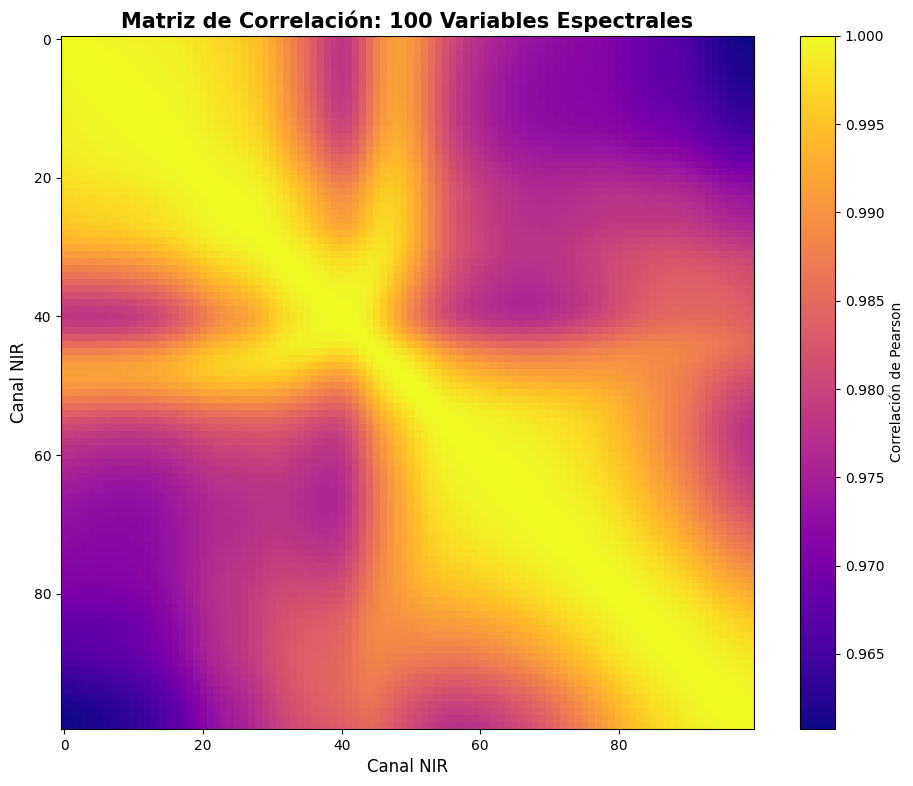

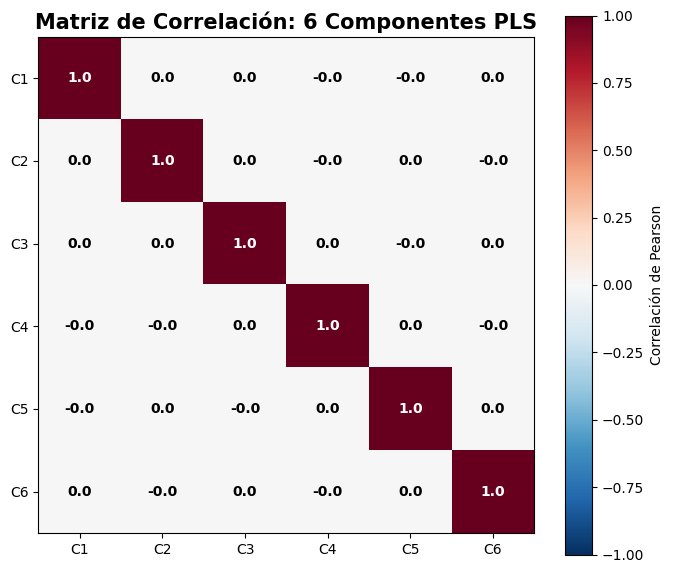

In [102]:
# 1. Correlación de las 100 variables originales
# Usamos pandas para asegurar un cálculo limpio de la matriz de correlación
df_X = pd.DataFrame(X_train_scaled)
corr_x = df_X.corr().values

plt.figure(figsize=(12, 9))
im1 = plt.imshow(corr_x, cmap='plasma', aspect='equal')
plt.title('Matriz de Correlación: 100 Variables Espectrales', fontsize=15, fontweight='bold')
plt.xlabel('Canal NIR', fontsize=12)
plt.ylabel('Canal NIR', fontsize=12)
plt.colorbar(im1, label='Correlación de Pearson')
plt.show()

# 2. Correlación de los 6 componentes PLS (Scores)
X_scores = pls.x_scores_
corr_pls = np.corrcoef(X_scores.T)

plt.figure(figsize=(8, 7))
im2 = plt.imshow(corr_pls, cmap='RdBu_r', aspect='equal', vmin=-1, vmax=1)
plt.title(f'Matriz de Correlación: {n_comp} Componentes PLS', fontsize=15, fontweight='bold')
plt.xticks(range(n_comp), [f'C{i+1}' for i in range(n_comp)])
plt.yticks(range(n_comp), [f'C{i+1}' for i in range(n_comp)])

for i in range(n_comp):
    for j in range(n_comp):
        plt.text(j, i, f'{corr_pls[i, j]:.1f}', ha='center', va='center', 
                 color='white' if abs(corr_pls[i, j]) > 0.5 else 'black', fontweight='bold')

plt.colorbar(im2, label='Correlación de Pearson')
plt.show()